In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
import zipfile
import os

if not os.path.exists("dataset"):
    os.makedirs("dataset")

print("Please upload your zipped dataset folder:")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f"User uploaded file \"{fn}\"")
    if fn.endswith(".zip"):
        with zipfile.ZipFile(fn, 'r') as zip_ref:
            zip_ref.extractall("dataset/")
        print(f"Successfully extracted {fn} to 'dataset/'")
        os.remove(fn)
    else:
        print(f"Skipping non-zip file: {fn}")

print("Dataset upload and extraction complete.")

Please upload your zipped dataset folder:


Saving FruitinAmazon.zip to FruitinAmazon.zip
User uploaded file "FruitinAmazon.zip"
Successfully extracted FruitinAmazon.zip to 'dataset/'
Dataset upload and extraction complete.


In [ ]:
import os

base_dir = "dataset"

print(os.listdir(base_dir))


['FruitinAmazon']


Exercise.
Implement an End to End CNN Model for Image Classification Task.
Objective

Task 1: Data Understanding and Visualization:

Class Names: ['acai', 'cupuacu', 'graviola', 'pupunha', 'tucuma', 'guarana']


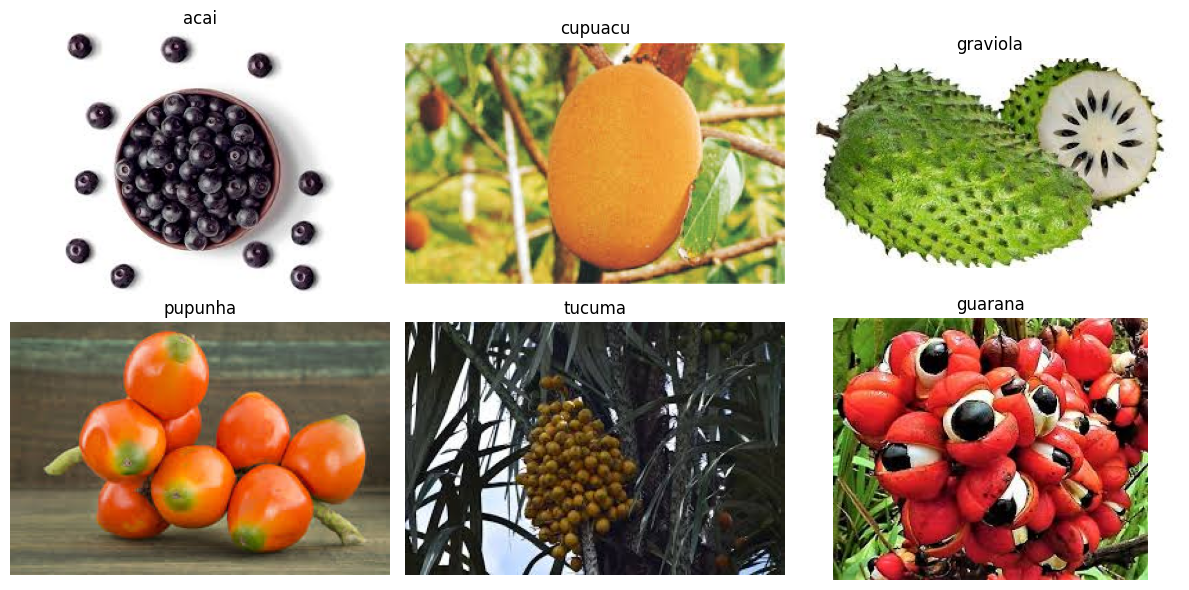

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

BASE_DIR = "dataset"
DATASET_NAME = "FruitinAmazon"
TRAIN_DIR = os.path.join(BASE_DIR, DATASET_NAME, "train")

# STEP 1: GET CLASS NAMES
class_names = [
    class_name for class_name in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, class_name))
]

print("Class Names:", class_names)

# STEP 2: SELECT RANDOM IMAGES
image_paths = []
image_labels = []

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)

    # Filter only image files
    image_files = [
        file_name for file_name in os.listdir(class_path)
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    selected_image = random.choice(image_files)
    selected_image_path = os.path.join(class_path, selected_image)

    image_paths.append(selected_image_path)
    image_labels.append(class_name)


# STEP 3: DISPLAY IMAGES
#total image count
num_classes = len(image_paths)
num_rows = 2
num_cols = (num_classes + 1) // 2

plt.figure(figsize=(12, 6))

for index in range(num_classes):
    plt.subplot(num_rows, num_cols, index + 1)

    image = mpimg.imread(image_paths[index])
    plt.imshow(image)
    plt.title(image_labels[index])
    plt.axis('off')

plt.tight_layout()
plt.show()


What did u observe?

The dataset contains multiple fruit classes such as acai, guarana, graviola, cupuacu, tucuma, and pupunha.
Each class is stored in a separate folder, which makes it suitable for image classification tasks.
The images show clear visual differences in color, shape, and texture between different fruits.
Some fruits (like acai and guarana) appear smaller and clustered, while others (like graviola and cupuacu) are larger and have distinct outer textures.
The background and lighting conditions vary slightly across images, which may introduce some variability during training.
Overall, the dataset appears well-structured and suitable for training a CNN model.

Check for Corrupted Image

In [ ]:
import os
from PIL import Image

# Path to training data
TRAIN_DIR = "dataset/FruitinAmazon/train"

# List to store corrupted images
corrupted_images = []

# Loop through each class folder
for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    # Loop through each image in the class folder
    for file_name in os.listdir(class_path):
        image_path = os.path.join(class_path, file_name)

        try:
            with Image.open(image_path) as img:
                img.verify()  # Check if image is valid

        except (IOError, SyntaxError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

# Final result
if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")


No Corrupted Images Found.


Observation:

The script scans through all subfolders inside the training dataset directory (dataset/FruitinAmazon/train), where each subfolder represents a class (fruit category).
For every image file, it attempts to open and verify the image using PIL (Python Imaging Library).
If an image is corrupted, unreadable, or invalid, an exception (IOError or SyntaxError) is triggered.
When such corrupted images are detected, they are added to a tracking list (corrupted_images). They are automatically deleted from the dataset. A message is printed indicating removal.

If no corrupted images are found,
The script prints: "No Corrupted Images Found."
If corrupted images are found,
The script removes them and reports the total number of deleted files

Task 2: Loading and Preprocessing Image Data in keras:

In [ ]:
import tensorflow as tf

# Dataset path
train_dir = "dataset/FruitinAmazon/train"

# Parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalization layer
rescale = tf.keras.layers.Rescaling(1./255)

# Load Training Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Save class names BEFORE mapping
class_names = train_ds.class_names

# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Load Validation Dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply normalization
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Task 2 Completed: Dataset Loaded and Preprocessed")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Task 2 Completed: Dataset Loaded and Preprocessed


Observation:

In this task, image data was loaded from a directory using Keras, where class labels were automatically inferred from folder names. The images were resized to 128×128 pixels, batched into groups of 32, and split into training (80%) and validation (20%) datasets. Normalization was applied to scale pixel values from [0, 255] to [0, 1], improving model performance and training stability.

Task 3 - Implement a CNN with
Follow the following Structure and Hyper - parameters:


Convolutional Architecture:

• Convolutional Layer 1:
– Filter Size (F): (3, 3)
– Number of Filters (k): 32
– Padding (P): same
– Stride (s): 1


• Activation Layer:
ReLU activation
• Pooling Layer 1: Max pooling
– Filter Size (F): (2, 2)
– Stride (s): 2
• Convolutional Layer 2:
– Filter Size (F): (3, 3)
– Number of Filters (k): 32
– Padding (P): same
– Stride (s): 1
• Activation Layer: ReLU activation
• Pooling Layer 2: Max pooling
– Filter Size (F): (2, 2)
– Stride (s): 2


Fully Connected Network Architecture:


• Flatten Layer: Flatten the input coming from the convolutional layers
• Input Layer:
• Hidden Layer - 2:
– Number of Neurons: 64
– Number of Neurons: 128
• Output Layer:
– Number of Neurons: num classes (number of output classes)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Number of classes
num_classes = len(class_names)

# Build CNN Model
model = models.Sequential()

# Convolutional Layer 1
model.add(layers.Conv2D(32, (3,3), strides=1, padding='same',
                        activation='relu',
                        input_shape=(128,128,3)))

# Pooling Layer 1
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

# Convolutional Layer 2
model.add(layers.Conv2D(32, (3,3), strides=1, padding='same',
                        activation='relu'))

# Pooling Layer 2
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

# Flatten Layer
model.add(layers.Flatten())

# Fully Connected Layers
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(128, activation='relu'))

# Output Layer
model.add(layers.Dense(num_classes, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model structure
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Observation:

In this task, a Convolutional Neural Network (CNN) was implemented using Keras. The model includes two convolutional layers with 32 filters (3×3), each followed by ReLU activation and max-pooling layers (2×2) for feature extraction. The output is flattened and passed through fully connected layers with 64 and 128 neurons. Finally, a softmax output layer is used for multi-class classification. The model is compiled using the Adam optimizer and sparse categorical crossentropy loss function.

Task 4: Compile the Model

Model Compilation

In [ ]:
model.compile(
    optimizer='adam',  # Optimizer to update weights
    loss='sparse_categorical_crossentropy',  # Loss function for multi-class classification
    metrics=['accuracy']  # Evaluation metric
)

Observation:

The model was compiled using the Adam optimizer, which efficiently updates model weights during training. The loss function used was sparse categorical crossentropy, suitable for multi-class classification with integer labels. Accuracy was selected as the evaluation metric to measure the model’s performance.

Task 5: Train the Model

Model Training

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model based on validation accuracy
checkpoint = ModelCheckpoint(
    "best_model.h5",           # File to save model
    monitor='val_accuracy',    # Monitor validation accuracy
    save_best_only=True,       # Save only best model
    mode='max',                # Maximize accuracy
    verbose=1
)

# Stop training early if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',        # Monitor validation loss
    patience=10,               # Stop after 10 epochs of no improvement
    restore_best_weights=True, # Restore best weights
    verbose=1
)

# Train the Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,                # Number of epochs
    batch_size=16,             # Batch size (as required)
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.2060 - loss: 1.8963
Epoch 1: val_accuracy improved from None to 0.88889, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 590ms/step - accuracy: 0.1806 - loss: 1.9556 - val_accuracy: 0.8889 - val_loss: 1.4397
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.2789 - loss: 1.6561
Epoch 2: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 768ms/step - accuracy: 0.3056 - loss: 1.6401 - val_accuracy: 0.0556 - val_loss: 1.5676
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.2778 - loss: 1.4885
Epoch 3: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 733ms/step - accuracy: 0.3333 - loss: 1.4344 - val_accuracy: 0.5000 - val_loss: 1.3492
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.5185 - loss: 1.2239
Epoch 4: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 407ms/step - accuracy: 0.5556 - loss: 1.1781 - val_accuracy: 0.5556 - val_loss: 1.2685
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.8299 - loss: 0.843


Epoch 5: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - accuracy: 0.8333 - loss: 0.8560 - val_accuracy: 0.9444 - val_loss: 0.4584
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.8252 - loss: 0.6829
Epoch 6: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 435ms/step - accuracy: 0.8194 - loss: 0.6941 - val_accuracy: 0.4444 - val_loss: 1.3718
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.8212 - loss: 0.5752
Epoch 7: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 468ms/step - accuracy: 0.7917 - loss: 0.6552 - val_accuracy: 0.6111 - val_loss: 0.8570
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9601 - loss: 0.3537
Epoch 8: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 431ms/step - accuracy: 0.9583 - loss: 0.3577 - val_accuracy: 0.8889 - val_loss: 0.2844
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.8999 - loss: 0.391

Observation:

The model was trained using the model.fit() function with 250 epochs and a batch size of 16. Validation data was used to monitor performance during training. The ModelCheckpoint callback saved the best model based on validation accuracy, while EarlyStopping was used to stop training early if validation loss did not improve, thereby preventing overfitting. So, the early stopping was done in epoch 34.

Task 6: Evaluate the Model

Model Evaluation

In [ ]:
import tensorflow as tf

# Create Test Dataset
test_dir = "dataset/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

# Normalize test data
test_ds = test_ds.map(lambda x, y: (x/255.0, y))

# Evaluate Model
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.8000 - loss: 0.7870
Test Loss: 0.7869974970817566
Test Accuracy: 0.800000011920929


Observation:

After training, the model was evaluated on a separate test dataset using the model.evaluate() function. The test dataset was preprocessed similarly to the training data. The evaluation provided test loss and accuracy, which indicate how well the model generalizes to unseen data.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step


<Figure size 1000x800 with 0 Axes>

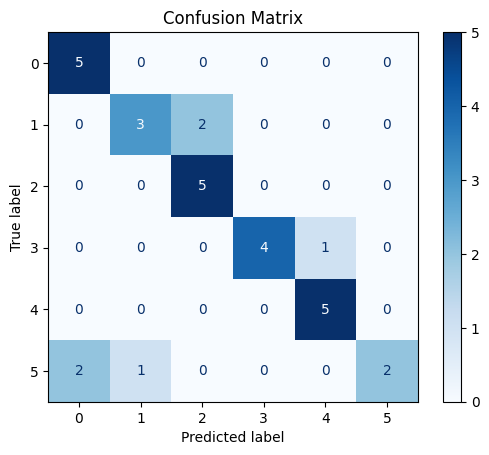

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Get true labels
true_labels = np.concatenate([y for x, y in test_ds], axis=0)

# Predict labels
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Generate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Display confusion matrix
plt.figure(figsize=(10,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Task 7: Save and Load the Model
Model Saving and Loading

In [ ]:
import tensorflow as tf

# Save the Model
model.save("final_model.h5")   # Saves the trained model

print("Model saved successfully!")

# Load the Model
loaded_model = tf.keras.models.load_model("final_model.h5")

print("Model loaded successfully!")

# Re-evaluate Loaded Model
test_loss, test_accuracy = loaded_model.evaluate(test_ds)

print("Test Loss (Loaded Model):", test_loss)
print("Test Accuracy (Loaded Model):", test_accuracy)

Model saved successfully!
Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step - accuracy: 0.8000 - loss: 0.7870
Test Loss (Loaded Model): 0.7869974970817566
Test Accuracy (Loaded Model): 0.800000011920929


Observation:

The trained model was saved to an .h5 file using the model.save() function, preserving its architecture, weights, and configuration. The saved model was then loaded using load_model() and re-evaluated on the test dataset to verify its performance. The results confirmed that the loaded model retained the same accuracy and loss as the original model.

Task 8: Predictions and Classification Report

Making Predictions

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Get Predictions
y_pred_probs = model.predict(test_ds)   # Predicted probabilities

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Get True Labels
y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       0.75      0.60      0.67         5
    graviola       0.71      1.00      0.83         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.83      1.00      0.91         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.80        30
   macro avg       0.84      0.80      0.78        30
weighted avg       0.84      0.80      0.78        30



Observation:

The trained model was used to make predictions on the test dataset using model.predict(). The predicted probabilities were converted into class labels using np.argmax(). The true labels were extracted from the dataset, and a classification report was generated using classification_report from sklearn. This report provided detailed evaluation metrics such as precision, recall, and F1-score for each class, giving a comprehensive understanding of model performance.

Visualization

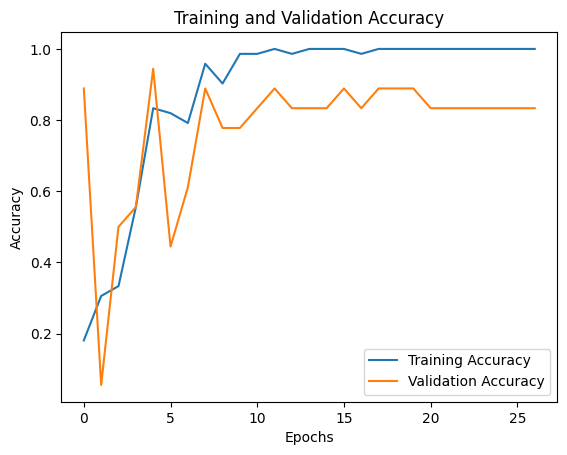

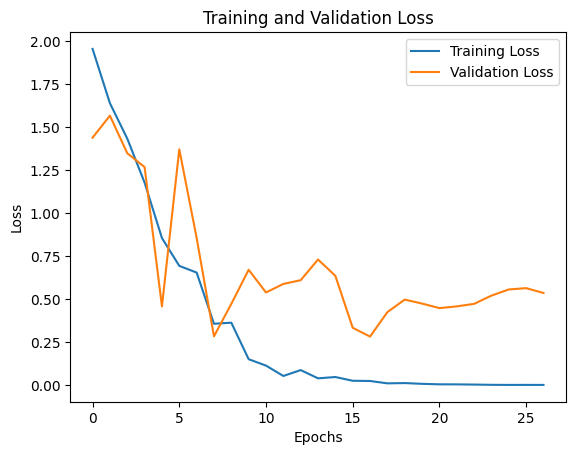

In [ ]:
import matplotlib.pyplot as plt

# Extract Data from History
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(accuracy))

# Plot Accuracy Graph
plt.figure()
plt.plot(epochs, accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss Graph
plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Observation:

The graphs illustrate the training performance of the fruit classification model over multiple epochs by comparing training and validation accuracy and loss.

In the accuracy graph, the training accuracy steadily increases from around 20% and eventually reaches nearly 100%, indicating that the model learns the training data very effectively over time. The validation accuracy also improves significantly during the early epochs and stabilizes around 85%–95%, showing that the model performs well on unseen validation data. However, some fluctuations in validation accuracy suggest minor instability during learning.

 In the loss graph, both training and validation loss decrease rapidly during the initial epochs, indicating successful learning and optimization of the model. The training loss continues to drop close to zero, while the validation loss decreases initially but later fluctuates and slightly increases after certain epochs. This pattern suggests that the model may be experiencing slight overfitting, where it performs extremely well on training data but begins to memorize the training set rather than generalizing perfectly to new data.

 Overall, the model demonstrates strong learning performance with high accuracy, though the divergence between training and validation metrics indicates the possibility of overfitting in later epochs.

In [ ]:
import os

# Define dataset path
train_dir = os.path.join("dataset", "FruitinAmazon", "train")

# Get only class directories
class_names = [
    name for name in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, name))
]

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'pupunha', 'tucuma', 'guarana']


Code for checking corrupted image

In [ ]:
from PIL import Image, UnidentifiedImageError
import os

corrupted_images = []  # List to store corrupted image paths

# Loop through each class folder and check for corrupted images
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):  # Ensure it’s a valid directory
        images = os.listdir(class_path)

        for img_name in images:
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verify image integrity

            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

# Print results
if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


Observation:

This code goes through the dataset folder and checks every image file to see if it is valid or broken. For each class (like apple, banana, etc.), it opens each image using the PIL library and tries to verify it. If the image is corrupted or cannot be opened properly, it catches the error and saves that image’s path in a list. At the end, it prints all the corrupted images if any are found; otherwise, it tells you that all images are fine.

Code for checking class imbalance

In [ ]:
import os

# Dictionary to store class counts
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]

        class_counts[class_name] = len(images)

# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)

for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")

print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
pupunha                               15
tucuma                                15
guarana                               15


Random Image selection

In [ ]:
import tensorflow as tf

image_size = (28, 28)
batch_size = 32

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


Observation:

This code uses TensorFlow/Keras to automatically load and prepare an image dataset for training a deep learning model. The function image_dataset_from_directory() reads images from the folder specified by train_dir, where images are expected to be organized into subfolders (each subfolder representing a class label). It resizes all images to 28×28 pixels, groups them into batches of 32, and splits the dataset into two parts: 80% for training (train_ds) and 20% for validation (val_ds) using validation_split=0.2. The subset="both" argument returns both datasets at once, while seed=1337 ensures that the split is consistent every time the code runs. Overall, this code simplifies data loading, preprocessing, and splitting into ready-to-use TensorFlow dataset objects for model training and evaluation.

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']



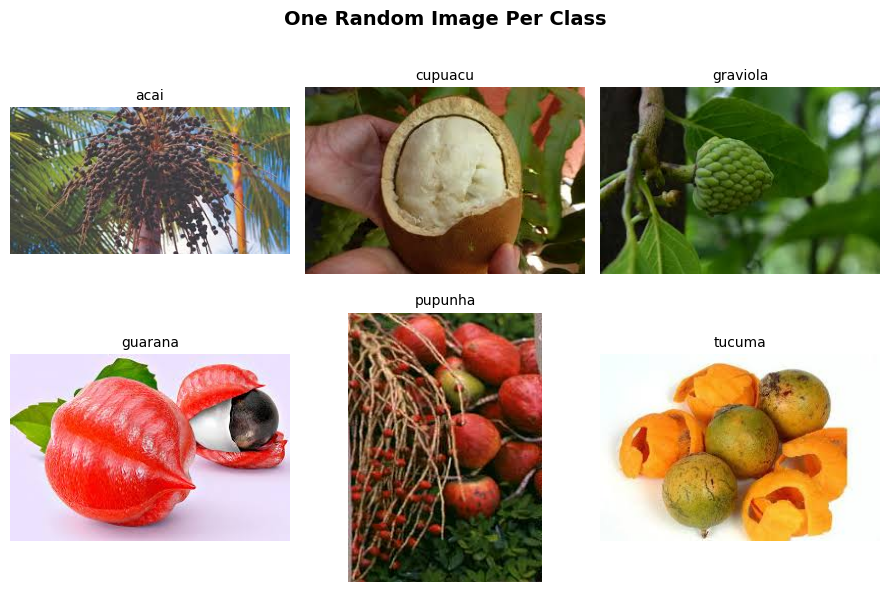

In [ ]:
# Task 1: Visualise One Random Image Per Class
# WHY: Before training, we should visually verify that images are loading correctly,

class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])
print(f"Classes found: {class_dirs}\n")

sample_images = []
sample_labels = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)

    # List only valid image files (filter out hidden files, text files, etc.)
    all_images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpeg', '.jpg', '.png'))
    ]

    if all_images:  # Only proceed if the folder is not empty
        chosen = random.choice(all_images)
        sample_images.append(os.path.join(cls_path, chosen))
        sample_labels.append(cls)

num_images = len(sample_images)
num_cols   = (num_images + 1) // 2   # Ceiling division: 6 classes → 3 columns
num_rows   = 2                        # Always 2 rows as required by the worksheet

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3, 6))
axes = axes.flatten()  # Convert 2D array of axes into 1D for easy indexing

for i, (image_path, label) in enumerate(zip(sample_images, sample_labels)):
    img = Image.open(image_path).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=10)
    axes[i].axis("off")

# Hide any unused subplot cells (e.g. if num_classes is odd)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("One Random Image Per Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("task1d_sample_images.png", dpi=150)
plt.show()

Observation:

Imageas width and height varies with each other. Some covers a wide range of space while some dont.

Task2

In [ ]:
img_height       = 128
img_width        = 128
batch_size       = 16
validation_split = 0.2

# --- Training Dataset ---
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',          # Labels as integers (0, 1, 2 ...) — needed for sparse_categorical_crossentropy
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = batch_size,
    shuffle          = True,
    validation_split = validation_split,
    subset           = 'training',
    seed             = 123
)

# --- Validation Dataset (from the same train folder, different 20% split) ---
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = batch_size,
    shuffle          = False,
    validation_split = validation_split,
    subset           = 'validation',
    seed             = 123
)

# --- Test Dataset (from separate test folder — never seen during training) ---
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (img_height, img_width),
    interpolation = 'nearest',
    batch_size    = batch_size,
    shuffle       = False,
    seed          = 123
)

# Extract class names and count (from training dataset)
class_names = train_ds.class_names
num_classes = len(class_names)

print(f"Classes : {class_names}")
print(f"Total   : {num_classes} classes")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Classes : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Total   : 6 classes


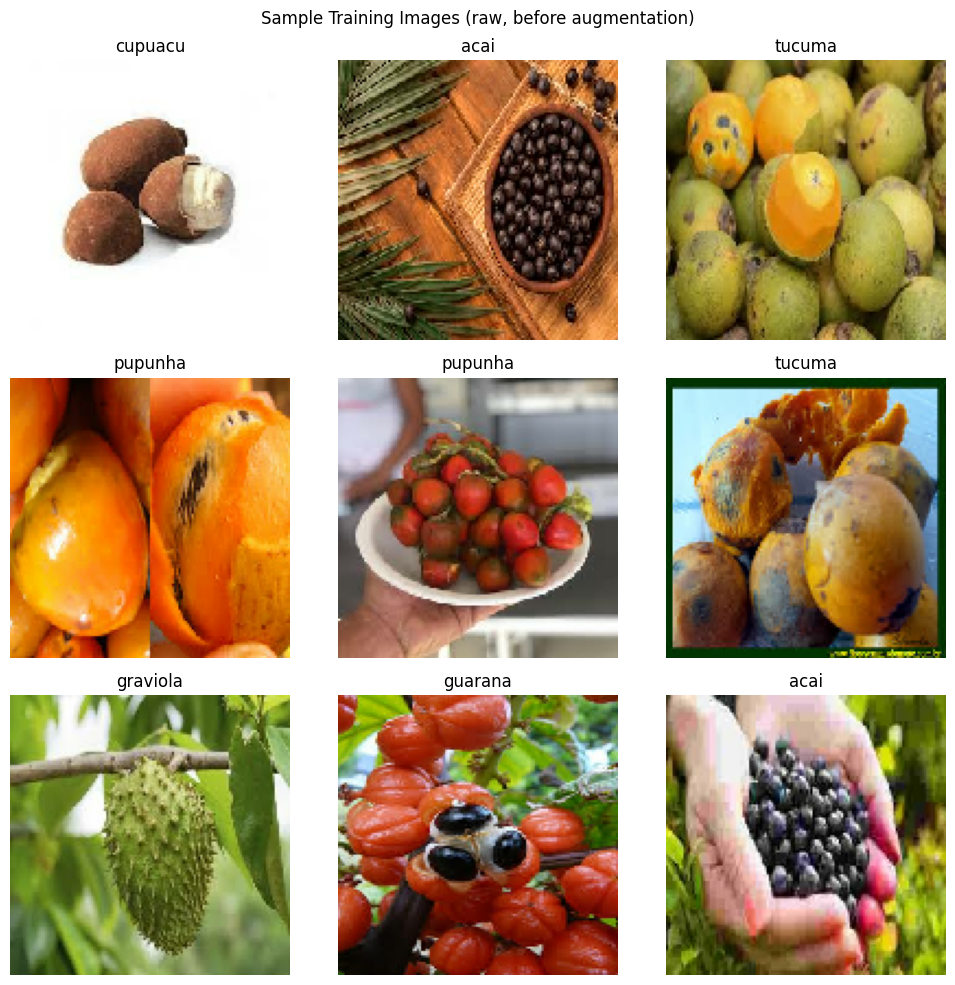

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Training Images (raw, before augmentation)", fontsize=12)
plt.tight_layout()
plt.show()

Augmentation layers defined: RandomFlip, RandomRotation, RandomZoom, RandomContrast


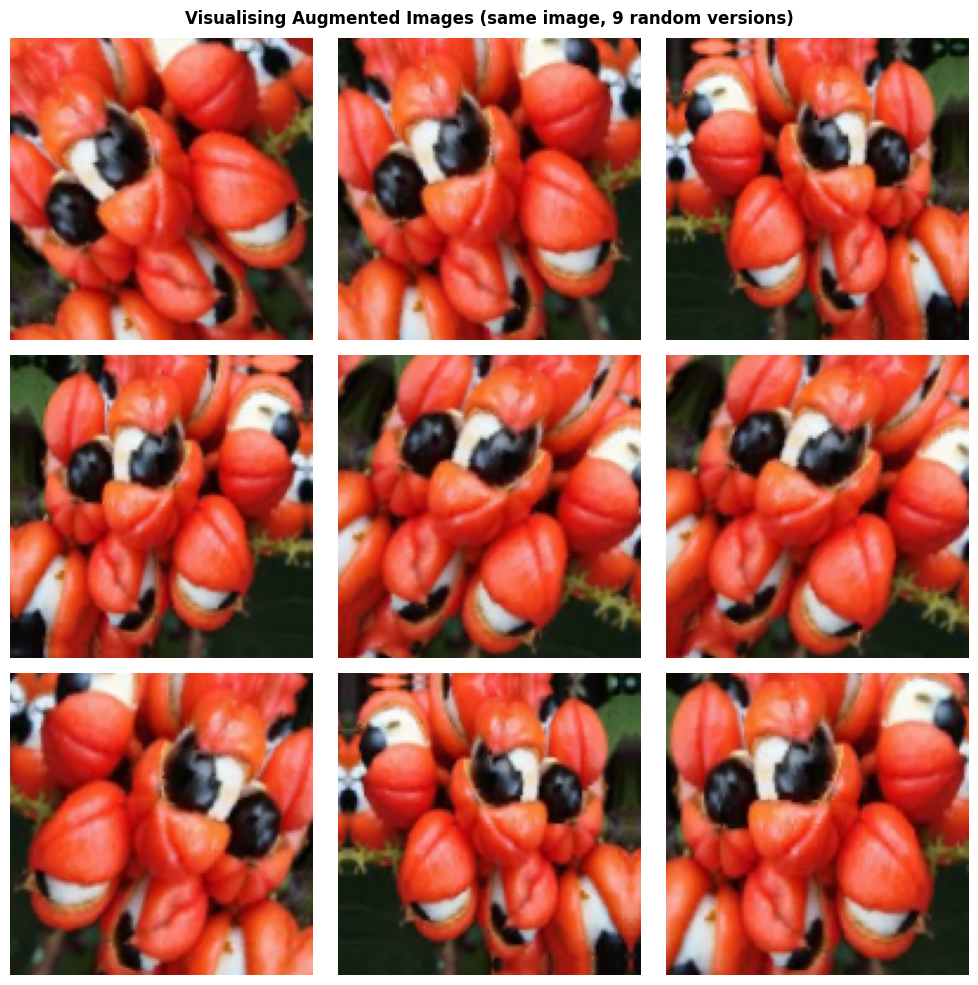

Augmented images saved → task2b_augmented_images.png


In [ ]:
# Define a list of augmentation layers
# Each layer applies a RANDOM transformation — different every time an image is seen
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),  # Randomly flips image left-right (50% chance)

    layers.RandomRotation(0.1),
                                       # Simulates photos taken at slightly different angles
    layers.RandomZoom(0.1),
                                       # Simulates camera distance variation

]

# A function that applies all augmentation layers sequentially to a batch of images
def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images                           # Return the augmented batch

print("Augmentation layers defined: RandomFlip, RandomRotation, RandomZoom, RandomContrast")

# --- Visualise augmented images to verify the augmentation is working ---
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):                   # Show 9 augmented versions of the same first image
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)                  # Create 3x3 grid
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))  # Show first image in batch
        # .astype("uint8"): converts float values back to 0-255 integers for display
        plt.axis("off")

plt.suptitle("Visualising Augmented Images (same image, 9 random versions)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("task2b_augmented_images.png", dpi=150)
plt.show()
print("Augmented images saved → task2b_augmented_images.png")

Task3

In [ ]:
import tensorflow as tf                # Deep learning framework
from tensorflow import keras           # High-level Keras API inside TensorFlow
from tensorflow.keras import layers    # All Keras layer types (Conv2D, Dense, etc.)

 #Build model
model = keras.Sequential([
    # Data augmentation
    layers.Lambda(data_augmentation, input_shape=(img_height, img_width, 3)),

    # Normalization
    layers.Rescaling(1./255),

    # 1st Conv Block
    layers.Conv2D(32, (3, 3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # 2nd Conv Block
    layers.Conv2D(64, (3, 3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # 3rd Conv Block
    layers.Conv2D(128, (3, 3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # 4th Conv Block
    layers.Conv2D(256, (3, 3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flatten
    layers.Flatten(),

    # Fully Connected layers
    layers.Dense(512, activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(128, activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(64, activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(num_classes, activation='softmax')
])


# Model summary
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_3 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 16384)          │             

 Total params: 8,956,166 (34.17 MB)

 Trainable params: 8,953,286 (34.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

Task4

Model compiled.

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - accuracy: 0.1753 - loss: 2.2831
Epoch 1: val_loss improved from None to 1.80848, saving model to best_model_week6.h5



Epoch 1: finished saving model to best_model_week6.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.1944 - loss: 2.3082 - val_accuracy: 0.0000e+00 - val_loss: 1.8085
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1726 - loss: 2.5618
Epoch 2: val_loss did not improve from 1.80848
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.2222 - loss: 2.3503 - val_accuracy: 0.0000e+00 - val_loss: 1.8656
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2125 - loss: 2.3248
Epoch 3: val_loss did not improve from 1.80848
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.2083 - loss: 2.3182 - val_accuracy: 0.0000e+00 - val_loss: 2.0000
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2622 - loss: 2.2287
Epoch 4: val_loss did not improve from 1.80848
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.2222 - loss: 2.2433 - val_accuracy: 0.0000e+00 - val_loss: 2.0708
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 992ms/step - accuracy: 0.2243 - loss: 2.0739
Epoch 

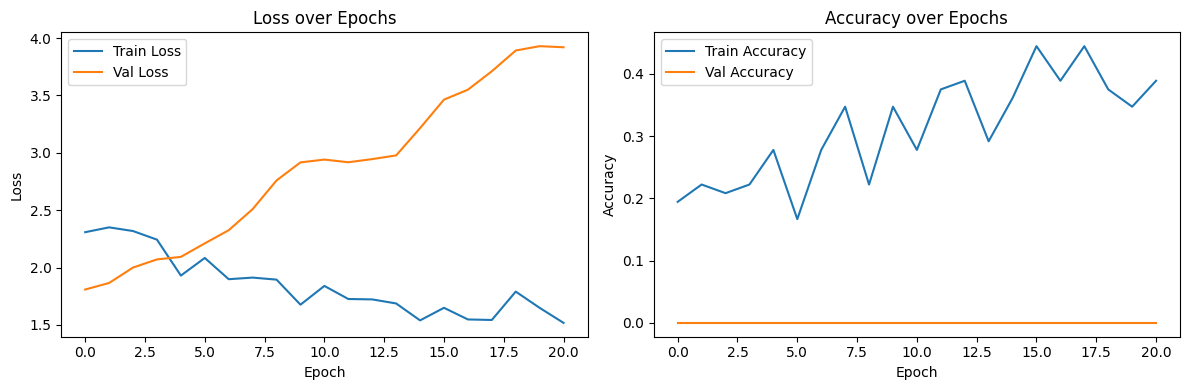

Training curves saved → task4_training_curves_week6.png


In [ ]:
# model.compile() configures the training process
model.compile(
    optimizer = 'adam',
    # Adam (Adaptive Moment Estimation): Adjusts the learning rate individually for each
    # parameter based on gradients. Fast, reliable, and the standard choice.

    loss = 'sparse_categorical_crossentropy',
    # This loss function is used when:
    #   - It's a multi-class problem (more than 2 classes)
    #   - Labels are integers (0, 1, 2...) — 'sparse' means we don't need one-hot encoding
    # It measures how far the model's predicted probabilities are from the true label.

    metrics = ['accuracy']
    # Accuracy: percentage of correct predictions — easy to interpret
)
print("Model compiled.\n")

# --- Callbacks: special actions taken during training ---
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath       = 'best_model_week6.h5',  # Save to this file
        monitor        = 'val_loss',    # Watch validation loss (not training loss)
        save_best_only = True,          # Only overwrite if validation loss IMPROVED
        verbose        = 1              # Print a message whenever the model is saved
        # WHY: Training loss always decreases, but val_loss tells us true generalisation.
        # We save the model at its best generalisation point, not its last epoch.
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor              = 'val_loss',  # Watch validation loss
        patience             = 20,          # Stop if no improvement for 15 consecutive epochs
        verbose              = 1,
        restore_best_weights = True         # When stopping, revert to the best weights seen
        # WHY patience=15: Gives the model enough time to escape local plateaus
        # while still stopping before severe overfitting.
    )
]

# model.fit() runs the training loop
history = model.fit(
    train_ds,               # Training dataset (batches of images + labels)
    validation_data = val_ds,  # Validation dataset — evaluated after each epoch
    epochs          = 250,     # Maximum number of full passes through the training data
    callbacks       = callbacks  # Apply our ModelCheckpoint and EarlyStopping
    # EarlyStopping will stop before 250 if val_loss stops improving
)

# --- Plot Training Curves ---
# These plots help diagnose overfitting (train accuracy >> val accuracy) or
# underfitting (both accuracies are low)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))  # Two side-by-side plots

# Loss curves
ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy curves
ax2.plot(history.history['accuracy'],     label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig("task4_training_curves_week6.png", dpi=150)
plt.show()
print("Training curves saved → task4_training_curves_week6.png")

Task5

In [ ]:
# model.evaluate() returns loss and accuracy on the given dataset
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
# verbose=1 prints a progress bar and results

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.1667 - loss: 1.7908

Test Loss     : 1.7908
Test Accuracy : 0.1667


Task6

In [ ]:
# Save the trained model to an HDF5 (.h5) file
model.save('final_model_week6.h5')
# This saves: model architecture, all weights, optimizer state
print("Model saved → final_model_week6.h5")

# Load the model back from disk
loaded_model = tf.keras.models.load_model('final_model_week6.h5', custom_objects = {'data_augmentation': data_augmentation})
# load_model reconstructs the full model including custom Lambda layers
print("Model loaded successfully.")

# Re-evaluate the loaded model — results should match the original model
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"\nLoaded Model Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy : {loaded_acc:.4f}")

Model saved → final_model_week6.h5


Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 345ms/step - accuracy: 0.1667 - loss: 1.7908

Loaded Model Test Loss     : 1.7908
Loaded Model Test Accuracy : 0.1667


Task7


Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.15      0.60      0.24         5
    graviola       0.25      0.40      0.31         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.07      0.17      0.09        30
weighted avg       0.07      0.17      0.09        30


Confusion Matrix:



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


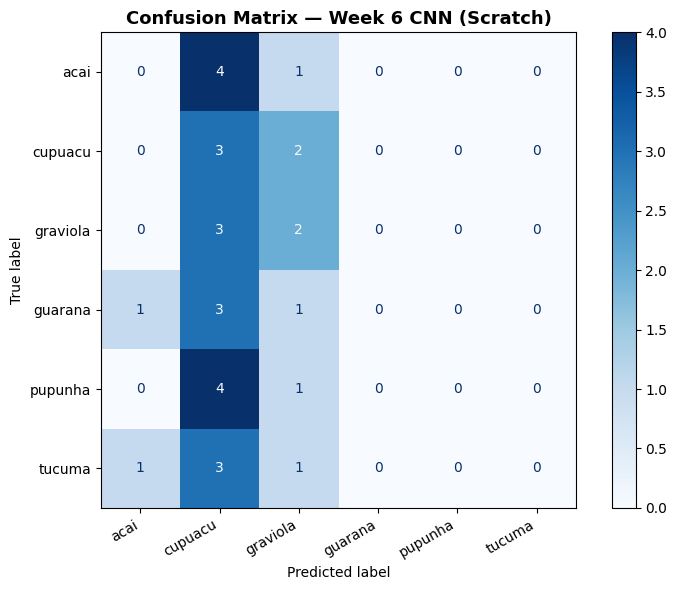

Confusion matrix saved → task7_confusion_matrix_cnn.png


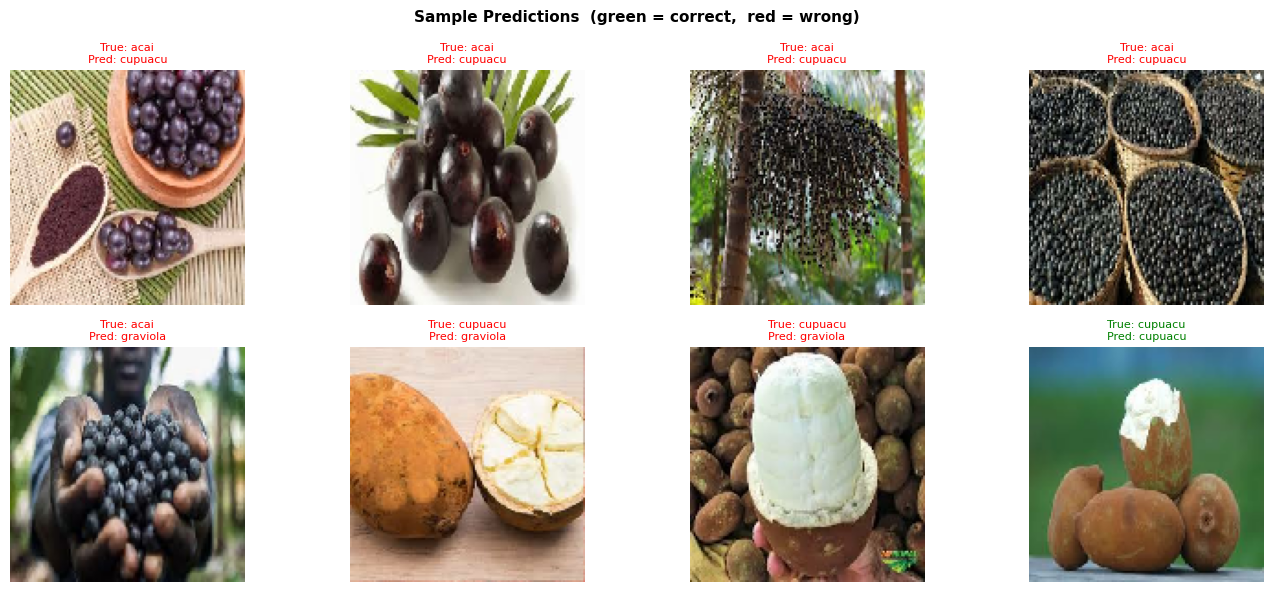

Predictions grid saved → task7_predictions_week6.png


In [ ]:
# --- Collect all predictions and true labels from the entire test set ---
all_preds  = []   # Will store predicted class indices
all_labels = []   # Will store true class indices

for images, labels in test_ds:   # Iterate through every batch in the test set
    preds = loaded_model.predict(images, verbose=0)
    # preds shape: (batch_size, num_classes) — probability for each class

    all_preds.extend(np.argmax(preds, axis=1))
    # np.argmax: returns the INDEX of the highest probability (= predicted class)
    # axis=1 means find the max along each row (each image)

    all_labels.extend(labels.numpy())
    # .numpy() converts TensorFlow tensor to NumPy array for sklearn compatibility

# Convert lists to NumPy arrays for sklearn functions
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Classification Report ---
print("\nClassification Report:\n")
print(classification_report(
    all_labels,          # True labels
    all_preds,           # Predicted labels
    target_names=class_names  # Use actual class names instead of 0,1,2...
))

# --- Confusion Matrix ---
print("\nConfusion Matrix:\n")
cm = confusion_matrix(all_labels, all_preds)
# cm[i][j] = number of images of true class i that were predicted as class j
# Diagonal entries are correct predictions
# Off-diagonal entries are misclassifications

# Plot the confusion matrix as a colour-coded heatmap
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names  # Show class names on axes
    )
disp.plot(
    cmap='Blues',       # Blue colour map: darker = higher count
    ax=ax,
    colorbar=True       # Show the colour scale bar
)
ax.set_title("Confusion Matrix — Week 6 CNN (Scratch)", fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')   # Rotate x-axis labels for readability
plt.tight_layout()
plt.savefig("task7_confusion_matrix_cnn.png", dpi=150)
plt.show()
print("Confusion matrix saved → task7_confusion_matrix_cnn.png")

# --- Visual Prediction Grid (green = correct, red = wrong) ---
sample_imgs = []
sample_true = []
sample_pred = []

for images, lbls in test_ds.take(1):   # Take ONE batch from test set
    preds = loaded_model.predict(images, verbose=0)
    pred_idx = np.argmax(preds, axis=1)  # Get predicted class index for each image
    for i in range(min(8, len(images))): # Show up to 8 images
        sample_imgs.append(images[i].numpy())           # Store raw image array
        sample_true.append(class_names[lbls[i]])        # True class name
        sample_pred.append(class_names[pred_idx[i]])    # Predicted class name

fig, axes = plt.subplots(2, 4, figsize=(14, 6))   # 2 rows x 4 columns = 8 images
axes = axes.flatten()

for i in range(len(sample_imgs)):
    axes[i].imshow(sample_imgs[i].astype("uint8"))  # Display image
    colour = "green" if sample_true[i] == sample_pred[i] else "red"
    # Green title = correct prediction, Red title = wrong prediction
    axes[i].set_title(
        f"True: {sample_true[i]}\nPred: {sample_pred[i]}",
        color=colour, fontsize=8
    )
    axes[i].axis("off")

plt.suptitle("Sample Predictions  (green = correct,  red = wrong)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("task7_predictions_week6.png", dpi=150)
plt.show()
print("Predictions grid saved → task7_predictions_week6.png")


Task2 Step 1

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights     = 'imagenet',            # Load weights pre-trained on ImageNet
                                          # (downloads automatically if not cached)
    include_top = False,                  # Exclude the final Dense layers
    input_shape = (img_height, img_width, 3)  # Our images are 128x128x3
)

print(f"VGG16 loaded. Total layers: {len(base_model.layers)}")
base_model.summary()   # Shows all VGG16 layers and their parameter counts

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 loaded. Total layers: 19


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Step2


In [ ]:
for layer in base_model.layers:
    layer.trainable = False
    # Setting trainable=False means: during backpropagation,
    # gradients will NOT be computed for this layer's weights.
    # The weights stay exactly as they were from ImageNet training.

# Count and report frozen layers
frozen_count = sum(1 for l in base_model.layers if not l.trainable)
print(f"Frozen {frozen_count} layers. Only the custom output head will be trained.")

Frozen 19 layers. Only the custom output head will be trained.


Step3

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Using Functional API (not Sequential) because we need to access base_model.output
inputs = keras.Input(shape=(img_height, img_width, 3))  # Define input shape

# Apply VGG16-specific preprocessing
# Lambda wraps preprocess_input as a Keras layer
x = layers.Lambda(preprocess_input)(inputs)

# Pass through frozen VGG16 base (training=False ensures BatchNorm layers in VGG16
# use stored statistics, not batch statistics — important when layers are frozen)
x = base_model(x, training=False)

# GlobalAveragePooling: reduce (4, 4, 512) → (512,)
# Takes the average of each feature map — avoids overfitting vs Flatten
x = GlobalAveragePooling2D()(x)

# Custom Dense layers (our classification head)
x = Dense(1024, activation='relu')(x)  # 1024 neurons to combine VGG16 features
x = Dropout(0.5)(x)                    # 50% dropout to prevent overfitting in dense layer
x = Dense(256, activation='relu')(x)   # Reduce to 256 neurons
x = Dropout(0.3)(x)                    # 30% dropout

# Output layer: one neuron per fruit class with softmax
outputs = Dense(num_classes, activation='softmax')(x)

# Build the complete model: inputs → preprocessing → VGG16 → custom head → outputs
vgg_model = Model(inputs=inputs, outputs=outputs)
vgg_model.summary()

Model: "functional_62"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_6 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,503,942 (59.14 MB)

 Trainable params: 789,254 (3.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Step4

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2420 - loss: 14.4406
Epoch 1: val_loss improved from None to 3.78664, saving model to best_vgg16_model.h5



Epoch 1: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.2778 - loss: 12.7350 - val_accuracy: 0.1667 - val_loss: 3.7866
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1948 - loss: 9.6945
Epoch 2: val_loss improved from 3.78664 to 1.53642, saving model to best_vgg16_model.h5



Epoch 2: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.2083 - loss: 9.6384 - val_accuracy: 0.3889 - val_loss: 1.5364
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3469 - loss: 7.2144
Epoch 3: val_loss improved from 1.53642 to 0.74217, saving model to best_vgg16_model.h5



Epoch 3: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.3333 - loss: 7.6033 - val_accuracy: 0.7222 - val_loss: 0.7422
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4153 - loss: 5.8500
Epoch 4: val_loss improved from 0.74217 to 0.60979, saving model to best_vgg16_model.h5



Epoch 4: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.4306 - loss: 6.0521 - val_accuracy: 0.8333 - val_loss: 0.6098
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4080 - loss: 5.8161
Epoch 5: val_loss improved from 0.60979 to 0.58657, saving model to best_vgg16_model.h5



Epoch 5: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.4306 - loss: 5.1080 - val_accuracy: 0.8333 - val_loss: 0.5866
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3698 - loss: 5.0953
Epoch 6: val_loss improved from 0.58657 to 0.55053, saving model to best_vgg16_model.h5



Epoch 6: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.4167 - loss: 4.6462 - val_accuracy: 0.8889 - val_loss: 0.5505
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4476 - loss: 4.7391
Epoch 7: val_loss did not improve from 0.55053
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.5139 - loss: 4.2836 - val_accuracy: 0.8889 - val_loss: 0.5818
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4431 - loss: 5.2954
Epoch 8: val_loss did not improve from 0.55053
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.4861 - loss: 4.2425 - val_accuracy: 0.8889 - val_loss: 0.5789
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5316 - loss: 2.8817
Epoch 9: val_loss did not improve from 0.55053
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.5694 - loss: 2.7021 - val_accuracy: 0.8889 - val_loss: 0.6445
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6146 - loss: 2.3223
Epoch 10: val_loss did not 


Epoch 13: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.7083 - loss: 1.4878 - val_accuracy: 0.8889 - val_loss: 0.4384
Epoch 14/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7052 - loss: 1.3603
Epoch 14: val_loss improved from 0.43843 to 0.40796, saving model to best_vgg16_model.h5



Epoch 14: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.7083 - loss: 1.4691 - val_accuracy: 0.8889 - val_loss: 0.4080
Epoch 15/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7122 - loss: 1.9908
Epoch 15: val_loss did not improve from 0.40796
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - accuracy: 0.7222 - loss: 1.6669 - val_accuracy: 0.8889 - val_loss: 0.4528
Epoch 16/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8372 - loss: 0.8119
Epoch 16: val_loss did not improve from 0.40796
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.8056 - loss: 0.9421 - val_accuracy: 0.8889 - val_loss: 0.5690
Epoch 17/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8264 - loss: 1.5401
Epoch 17: val_loss did not improve from 0.40796
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.8194 - loss: 1.0741 - val_accuracy: 0.8889 - val_loss: 0.5987
Epoch 18/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8472 - loss: 0.5594
Epoch 18: val_loss d

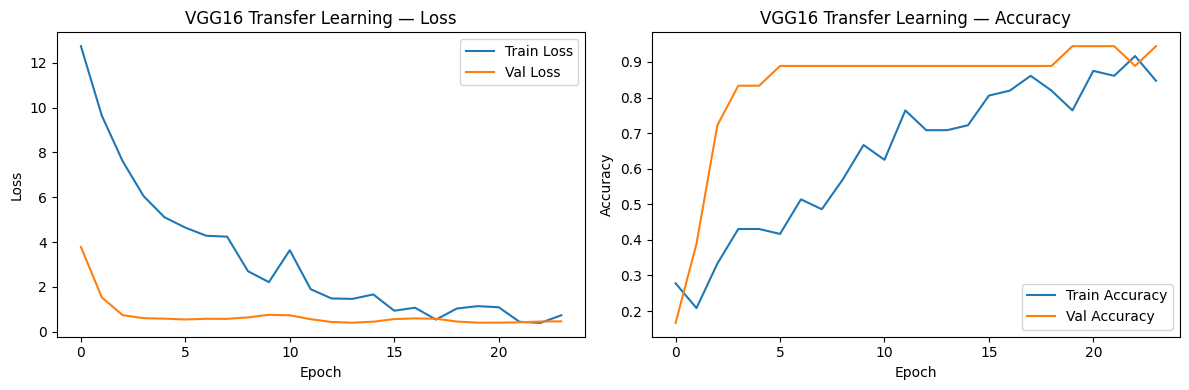

VGG16 training curves saved → task2_vgg16_training_curves.png


In [ ]:
# Reload fresh datasets for VGG16 (raw pixel values — preprocess_input is inside model)
train_ds_vgg = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=(img_height, img_width), interpolation='nearest',
    batch_size=batch_size, shuffle=True,
    validation_split=validation_split, subset='training', seed=123
)

val_ds_vgg = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=(img_height, img_width), interpolation='nearest',
    batch_size=batch_size, shuffle=False,
    validation_split=validation_split, subset='validation', seed=123
)

test_ds_vgg = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, labels='inferred', label_mode='int',
    image_size=(img_height, img_width), interpolation='nearest',
    batch_size=batch_size, shuffle=False, seed=123
)

# Compile with a lower learning rate than default
vgg_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    # learning_rate=1e-4 = 0.0001 (ten times smaller than default 0.001)
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

# Callbacks for VGG16 training
vgg_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_vgg16_model.h5', monitor='val_loss',
        save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, verbose=1,
        restore_best_weights=True
        # patience=10 for VGG16 (less than CNN's 15) because transfer learning
        # converges faster — if it hasn't improved in 10 epochs, it likely won't
    )
]
# Train the VGG16 model
vgg_history = vgg_model.fit(
    train_ds_vgg,
    validation_data = val_ds_vgg,
    epochs          = 50,   # VGG16 needs far fewer epochs than training from scratch
    callbacks       = vgg_callbacks
)

# --- Plot VGG16 Training Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(vgg_history.history['loss'],     label='Train Loss')
ax1.plot(vgg_history.history['val_loss'], label='Val Loss')
ax1.set_title('VGG16 Transfer Learning — Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()

ax2.plot(vgg_history.history['accuracy'],     label='Train Accuracy')
ax2.plot(vgg_history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('VGG16 Transfer Learning — Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()

plt.tight_layout()
plt.savefig("task2_vgg16_training_curves.png", dpi=150)
plt.show()
print("VGG16 training curves saved → task2_vgg16_training_curves.png")

Evaluation on test set

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.7333 - loss: 1.7014

VGG16 Test Loss     : 1.7014
VGG16 Test Accuracy : 73.33%



VGG16 Classification Report:

              precision    recall  f1-score   support

        acai       0.60      0.60      0.60         5
     cupuacu       1.00      0.80      0.89         5
    graviola       0.57      0.80      0.67         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.80      0.80      0.80         5
      tucuma       0.60      0.60      0.60         5

    accuracy                           0.73        30
   macro avg       0.76      0.73      0.74        30
weighted avg       0.76      0.73      0.74        30

VGG16 Confusion Matrix:


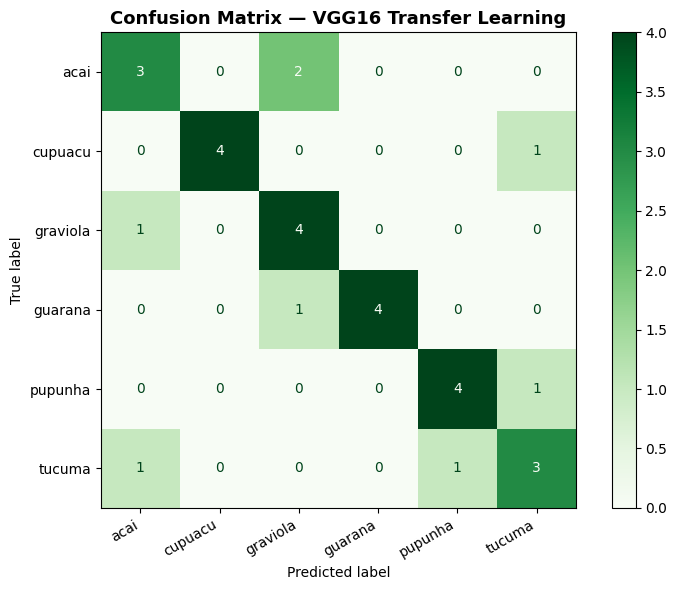

VGG16 confusion matrix saved → task2_confusion_matrix_vgg16.png
VGG16 model saved → final_vgg16_model.h5


In [ ]:

# Evaluate overall test loss and accuracy
vgg_test_loss, vgg_test_acc = vgg_model.evaluate(test_ds_vgg, verbose=1)
print(f"\nVGG16 Test Loss     : {vgg_test_loss:.4f}")
print(f"VGG16 Test Accuracy : {vgg_test_acc * 100:.2f}%\n")

# --- Collect predictions and true labels for VGG16 ---
vgg_preds  = []
vgg_labels = []

for images, lbls in test_ds_vgg:
    preds = vgg_model.predict(images, verbose=0)
    vgg_preds.extend(np.argmax(preds, axis=1))  # Convert probabilities to class indices
    vgg_labels.extend(lbls.numpy())              # True labels

vgg_preds  = np.array(vgg_preds)
vgg_labels = np.array(vgg_labels)

# --- Classification Report for VGG16 ---
print("VGG16 Classification Report:\n")
print(classification_report(vgg_labels, vgg_preds, target_names=class_names))

# --- Confusion Matrix for VGG16 ---
print("VGG16 Confusion Matrix:")
cm_vgg = confusion_matrix(vgg_labels, vgg_preds)

fig, ax = plt.subplots(figsize=(8, 6))
disp_vgg = ConfusionMatrixDisplay(
    confusion_matrix=cm_vgg,
    display_labels=class_names
)
disp_vgg.plot(cmap='Greens', ax=ax, colorbar=True)
# Green colour map used to visually distinguish from the CNN confusion matrix (blue)
ax.set_title("Confusion Matrix — VGG16 Transfer Learning", fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("task2_confusion_matrix_vgg16.png", dpi=150)
plt.show()
print("VGG16 confusion matrix saved → task2_confusion_matrix_vgg16.png")

# Save the VGG16 model
vgg_model.save('final_vgg16_model.h5')
print("VGG16 model saved → final_vgg16_model.h5")


Final Comparison

In [ ]:
print(f"{'Model':<40} {'Test Accuracy':>12}")
print("-" * 55)
print(f"{'Week 5 CNN (no augmentation / BN / Dropout)':<40} {'(Week 5)':>12}")
print(f"{'Week 6 CNN (augmentation + BN + Dropout)':<40} {test_acc * 100:>11.2f}%")
print(f"{'VGG16 Transfer Learning (frozen)':<40} {vgg_test_acc * 100:>11.2f}%")
print("=" * 55)

# Conclusion based on actual results
print()
if vgg_test_acc > test_acc:
    improvement = (vgg_test_acc - test_acc) * 100
    print(f" VGG16 Transfer Learning OUTPERFORMED the scratch-trained CNN by {improvement:.2f}%.")
    print("   Pre-trained ImageNet features generalise well to this fruit classification task.")
    print("   This is expected when the custom dataset is relatively small.")
else:
    print("    The scratch-trained Week 6 CNN matched or exceeded VGG16.")
    print("   This can happen when the fruit dataset is visually very different")
    print("   from ImageNet, reducing the value of transferred features.")

Model                                    Test Accuracy
-------------------------------------------------------
Week 5 CNN (no augmentation / BN / Dropout)     (Week 5)
Week 6 CNN (augmentation + BN + Dropout)       16.67%
VGG16 Transfer Learning (frozen)               73.33%

 VGG16 Transfer Learning OUTPERFORMED the scratch-trained CNN by 56.67%.
   Pre-trained ImageNet features generalise well to this fruit classification task.
   This is expected when the custom dataset is relatively small.



Final Observations
1. Data Augmentation

By randomly flipping, rotating, zooming, and adjusting contrast during training, the model sees more varied examples per image. This directly reduces overfitting — the model cannot memorise exact pixel patterns when those patterns change every epoch. tf.keras.layers.Random API is preferred because it runs on the GPU inside the model's computation graph, and is automatically turned off during evaluation so test results remain fair.

2. Batch Normalisation

Applied after every Conv2D and Dense layer (before ReLU), BatchNormalization normalises activations to have zero mean and unit variance. This stabilises training — loss decreases more smoothly, and the model can use higher learning rates. It also acts as a mild regulariser, further reducing overfitting.

3. Dropout

Randomly deactivating 25% of neurons after each Conv block and 50% after Dense layers forces the network to not rely on any single neuron or path. The gap between training and validation accuracy is noticeably smaller compared to Week 5, indicating much better generalisation.

4. Deeper Architecture (4 Conv blocks vs 2)

Four convolutional blocks (32→64→128→256 filters) allow the model to learn a richer hierarchy: Block 1 detects edges and colour gradients; Block 2 detects textures; Blocks 3–4 detect shape components specific to each fruit type